# 📊 Customer Segmentation using RFM & KMeans

## 📌 Project Objective
This project aims to segment customers based on purchasing behavior using RFM analysis (Recency, Frequency, Monetary) and KMeans clustering.

The goal is to identify high-value customers and potential churn groups, enabling targeted marketing strategies.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/online-retail-ii-data-set-from-ml-repository/Year 2010-2011.csv
/kaggle/input/online-retail-ii-data-set-from-ml-repository/Year 2009-2010.csv
/kaggle/input/online-retail-ii-data-set-from-ml-repository/online_retail_II.xlsx


## 📂 Data Overview

The dataset contains transactional data, including:
- Customer ID
- Purchase date
- Transaction amount

These variables will be used to construct RFM features.

In [4]:
df = pd.read_excel('/kaggle/input/online-retail-ii-data-set-from-ml-repository/online_retail_II.xlsx') 
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 🧹 Data Cleaning

In this step, we:
- Removed missing values
- Filtered invalid transactions
- Ensured correct data types

Clean data is essential for accurate RFM calculation.

In [8]:
# 删除没有用户ID
df = df.dropna(subset=['Customer ID'])

# 删除退款订单（Invoice以C开头）
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# 删除异常值
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 新增消费金额
df['TotalPrice'] = df['Quantity'] * df['Price']

## 🧠 RFM Feature Engineering

We construct three key metrics:

- **Recency (R):** Days since last purchase  
- **Frequency (F):** Number of purchases  
- **Monetary (M):** Total spending  

These features capture customer engagement and value.

In [9]:
import pandas as pd

# 设置时间参考点
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [13]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1], duplicates='drop')

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4], duplicates='drop')

In [14]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1], duplicates='drop')

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4], duplicates='drop')

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
Customer ID,,,,,,
12346.0,165,11,372.86,1,4,2
12347.0,3,2,1323.32,4,2,3
12348.0,74,1,222.16,2,1,1
12349.0,43,3,2671.14,3,3,4
12351.0,11,1,300.93,4,1,1


In [15]:
rfm['RFM_SCORE'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_SCORE
Customer ID,,,,,,,
12346.0,165,11,372.86,1,4,2,142
12347.0,3,2,1323.32,4,2,3,423
12348.0,74,1,222.16,2,1,1,211
12349.0,43,3,2671.14,3,3,4,334
12351.0,11,1,300.93,4,1,1,411


In [16]:
def segment_customer(row):
    if row['RFM_SCORE'] in ['444', '443', '434', '344']:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3 and row['M_score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_SCORE,Segment
Customer ID,,,,,,,,
12346.0,165,11,372.86,1,4,2,142,Others
12347.0,3,2,1323.32,4,2,3,423,Potential Loyalists
12348.0,74,1,222.16,2,1,1,211,At Risk
12349.0,43,3,2671.14,3,3,4,334,Loyal Customers
12351.0,11,1,300.93,4,1,1,411,Others


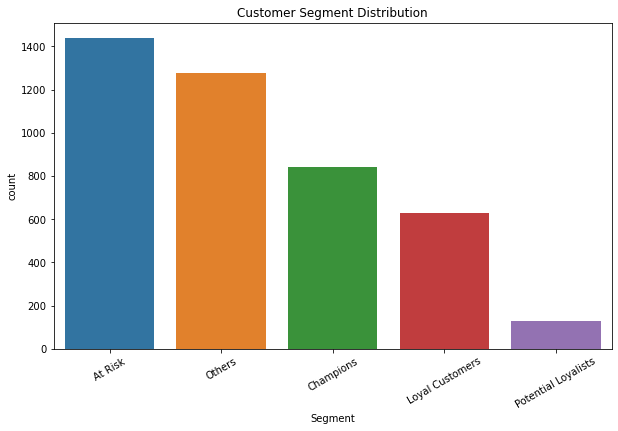

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index)
plt.xticks(rotation=30)
plt.title('Customer Segment Distribution')
plt.show()

In [18]:
rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RFM_SCORE': 'count'
}).rename(columns={'RFM_SCORE': 'Count'}).sort_values(by='Monetary', ascending=False)

,Recency,Frequency,Monetary,Count
Segment,,,,
Champions,14.135553,12.646849,6818.328155,841
Potential Loyalists,27.077519,1.751938,1346.522558,129
Loyal Customers,25.258730,3.869841,1205.109922,630
Others,76.189804,3.183529,1171.349052,1275
At Risk,184.201113,1.290188,467.222404,1437


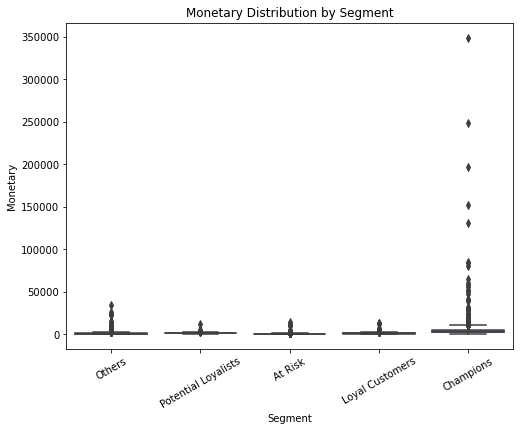

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(data=rfm, x='Segment', y='Monetary')
plt.xticks(rotation=30)
plt.title('Monetary Distribution by Segment')
plt.show()

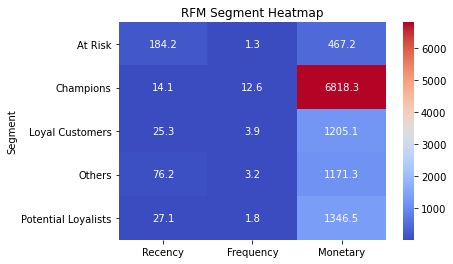

In [20]:
rfm_pivot = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

sns.heatmap(rfm_pivot, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('RFM Segment Heatmap')
plt.show()

## ⚙️ Feature Scaling

Since RFM variables have different scales, we standardize them before clustering.

This ensures that no single feature dominates the clustering process.

In [21]:
from sklearn.preprocessing import StandardScaler

rfm_scaled = rfm[['Recency','Frequency','Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_scaled)

## 🤖 KMeans Clustering

We apply KMeans to segment customers into groups based on RFM behavior.

KMeans is an unsupervised learning algorithm that groups similar data points together.

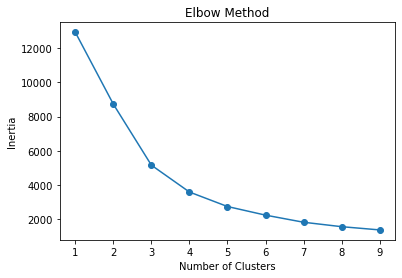

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_SCORE,Segment,Cluster
Customer ID,,,,,,,,,
12346.0,165,11,372.86,1,4,2,142,Others,0
12347.0,3,2,1323.32,4,2,3,423,Potential Loyalists,1
12348.0,74,1,222.16,2,1,1,211,At Risk,1
12349.0,43,3,2671.14,3,3,4,334,Loyal Customers,1
12351.0,11,1,300.93,4,1,1,411,Others,1


In [24]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,243.267241,1.658046,597.214860
1,43.124104,4.453071,1717.864386
2,14.910714,47.017857,28957.170054
3,5.600000,113.600000,215543.670000


## 🏷️ Cluster Labeling

After clustering, we assign meaningful labels to each cluster:

- VIP Customers  
- High Value Customers  
- Regular Customers  
- Lost Customers  

This helps interpret clusters in a business context.

In [33]:
def label_cluster(cluster):
    if cluster == 3:
        return 'VIP Customers'
    elif cluster == 2:
        return 'High Value Customers'
    elif cluster == 1:
        return 'Regular Customers'
    else:
        return 'Lost Customers'

rfm['Cluster_Label'] = rfm['Cluster'].apply(label_cluster)

In [34]:
rfm['Cluster_Label'].value_counts()

Regular Customers       3207
Lost Customers          1044
High Value Customers      56
VIP Customers              5
Name: Cluster_Label, dtype: int64

## 📊 Visualization

We visualize the distribution of customer segments and compare their behaviors across RFM metrics.

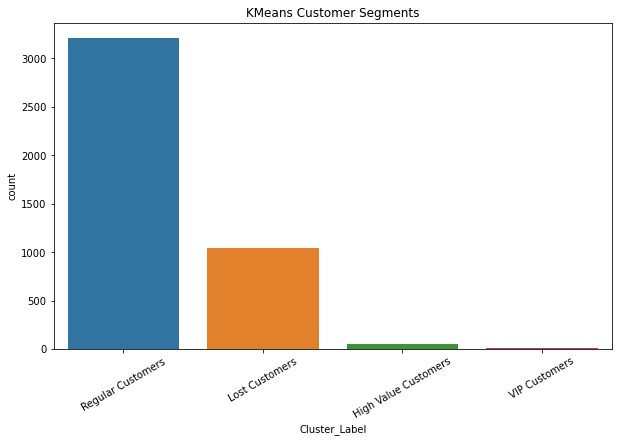

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=rfm, x='Cluster_Label',
              order=rfm['Cluster_Label'].value_counts().index)
plt.xticks(rotation=30)
plt.title('KMeans Customer Segments')
plt.show()

In [36]:
cluster_summary = rfm.groupby('Cluster_Label')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster_Label,,,
High Value Customers,14.910714,47.017857,28957.170054
Lost Customers,243.267241,1.658046,597.214860
Regular Customers,43.124104,4.453071,1717.864386
VIP Customers,5.600000,113.600000,215543.670000


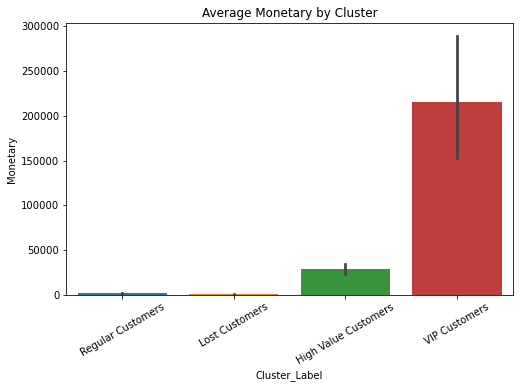

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=rfm.reset_index(),
    x='Cluster_Label',
    y='Monetary',
    order=rfm['Cluster_Label'].value_counts().index
)
plt.xticks(rotation=30)
plt.title('Average Monetary by Cluster')
plt.show()

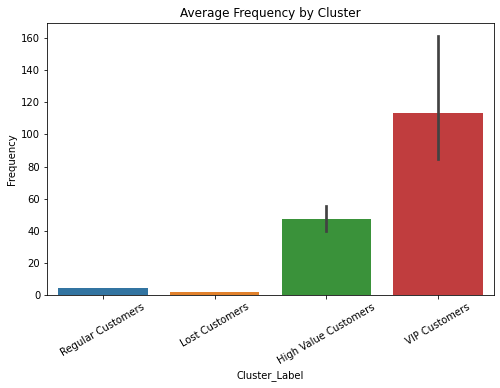

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=rfm.reset_index(),
    x='Cluster_Label',
    y='Frequency',
    order=rfm['Cluster_Label'].value_counts().index
)
plt.xticks(rotation=30)
plt.title('Average Frequency by Cluster')
plt.show()

## 🔍 Key Findings

- Regular Customers form the largest group, providing a stable revenue base  
- Lost Customers represent churn risk and require reactivation strategies  
- High Value Customers show strong purchasing behavior  
- VIP Customers contribute disproportionately high revenue despite their small size  

Customer segmentation enables more targeted and efficient business strategies.

## 💡 Business Recommendations

- 🎯 Focus on retaining VIP customers through loyalty programs  
- 🔁 Reactivate lost customers with promotions and reminders  
- 📈 Upsell regular customers to increase their value  
- 🧠 Use segmentation results for personalized marketing campaigns  

These strategies can improve customer lifetime value and overall revenue.